# Macro-$F_1$ vs Gini coefficient

Recreates `plot_data/plots/fig7_gini.pdf` (Fig. `fig:gini`).

Macro-$F_1$ for the five imbalance experiments (E1–E5) versus their Gini
coefficient, for all six models on the **spurious** ($\mathbf{R}_{L1}$) test
outputs, from **5-fold cross-validation**. Each point is the mean macro-$F_1$
over the 5 folds; the translucent bubble diameter is proportional to the
standard deviation across the 5 folds.

**Data:** per-run confusion-matrix tables under
`plot_data/collected_wandb_metrics_gini_experiments_5_fold/`
(6 models × 5 folds × 5 experiments, spurious). Macro-$F_1$ is computed from
each confusion matrix (label-agnostic: baselines use `0..3`, BYOL uses class names).


In [1]:
import glob
import json
import os
import re

import matplotlib.pyplot as plt
import numpy as np

DATA_DIR = "/home/gate/rgc/plot_data/collected_wandb_metrics_gini_experiments_5_fold"
OUT_DIR = "/home/gate/rgc/plot_data/plots"
OUT_PDF = f"{OUT_DIR}/fig7_gini.pdf"
OUT_PNG = f"{OUT_DIR}/fig7_gini.png"

# Gini coefficient per imbalance experiment (Table tab:imbalance_experiments)
GINI = {"E1": 0.000, "E2": 0.035, "E3": 0.070, "E4": 0.105, "E5": 0.140}

# folder model token -> serial; colours/order follow the Grad-CAM notebook.
MODEL_SERIAL = {
    "convnext_base": "M1", "byol_dsteerable_downstream": "M2", "vgg16": "M3",
    "swin_b": "M4", "resnet50": "M5", "vit_b_16": "M6",
}
MODEL_COLOR = {
    "M1": "#bf5af2", "M2": "#0a84ff", "M3": "#34c759",
    "M4": "#ffcc00", "M5": "#ff9500", "M6": "#ff3b30",
}
MODEL_ORDER = ["M1", "M2", "M3", "M4", "M5", "M6"]

In [2]:
def macro_f1_from_cm(path):
    """Macro-F1 from a wandb confusion-matrix table (label-agnostic)."""
    data = json.load(open(path))["data"]
    cm, labels = {}, set()
    for actual, pred, n in data:
        cm[(actual, pred)] = cm.get((actual, pred), 0.0) + float(n)
        labels.update((actual, pred))
    classes = sorted(labels)
    f1s = []
    for c in classes:
        tp = cm.get((c, c), 0.0)
        fp = sum(cm.get((a, c), 0.0) for a in classes if a != c)
        fn = sum(cm.get((c, p), 0.0) for p in classes if p != c)
        prec = tp / (tp + fp) if tp + fp else 0.0
        rec = tp / (tp + fn) if tp + fn else 0.0
        f1s.append(2 * prec * rec / (prec + rec) if prec + rec else 0.0)
    return float(np.mean(f1s))


def model_serial(fn):
    for tok, serial in MODEL_SERIAL.items():
        if f"_spurious_{tok}_" in fn:
            return serial
    return None


def collect():
    """{serial: {E: (gini, mean_f1, std_f1)}} over 5 folds."""
    per = {}  # (serial, E) -> {fold: macro_f1}
    for f in glob.glob(os.path.join(DATA_DIR, "*.json")):
        fn = os.path.basename(f)
        serial = model_serial(fn)
        if serial is None:
            continue
        exp = re.search(r"_(E[1-5])_", fn).group(1)
        fold = int(re.search(r"fold_(\d+)_", fn).group(1))
        per.setdefault((serial, exp), {})[fold] = macro_f1_from_cm(f)

    out = {}
    for (serial, exp), folds in per.items():
        vals = np.array(list(folds.values()))
        out.setdefault(serial, {})[exp] = (GINI[exp], float(vals.mean()), float(vals.std()))
    return out


data = collect()

print("mean macro-F1 (std) over 5 folds -- R_L1 (spurious)")
print("      " + "  ".join(f"{e}(g{GINI[e]:.3f})" for e in ["E1", "E2", "E3", "E4", "E5"]))
for serial in MODEL_ORDER:
    pts = data.get(serial, {})
    cells_ = [f"{pts[e][1]:.3f}({pts[e][2]:.3f})" if e in pts else "   --    "
              for e in ["E1", "E2", "E3", "E4", "E5"]]
    print(f"{serial}: " + " ".join(cells_))

mean macro-F1 (std) over 5 folds -- R_L1 (spurious)
      E1(g0.000)  E2(g0.035)  E3(g0.070)  E4(g0.105)  E5(g0.140)
M1: 0.777(0.012) 0.778(0.022) 0.790(0.028) 0.785(0.038) 0.776(0.030)
M2: 0.767(0.035) 0.772(0.019) 0.762(0.022) 0.765(0.035) 0.755(0.025)
M3: 0.719(0.024) 0.764(0.016) 0.732(0.025) 0.741(0.019) 0.736(0.032)
M4: 0.715(0.021) 0.750(0.027) 0.733(0.028) 0.718(0.034) 0.729(0.029)
M5: 0.694(0.010) 0.706(0.009) 0.704(0.015) 0.690(0.031) 0.701(0.034)
M6: 0.665(0.034) 0.633(0.037) 0.633(0.039) 0.628(0.039) 0.649(0.028)


wrote /home/gate/rgc/plot_data/plots/fig7_gini.pdf


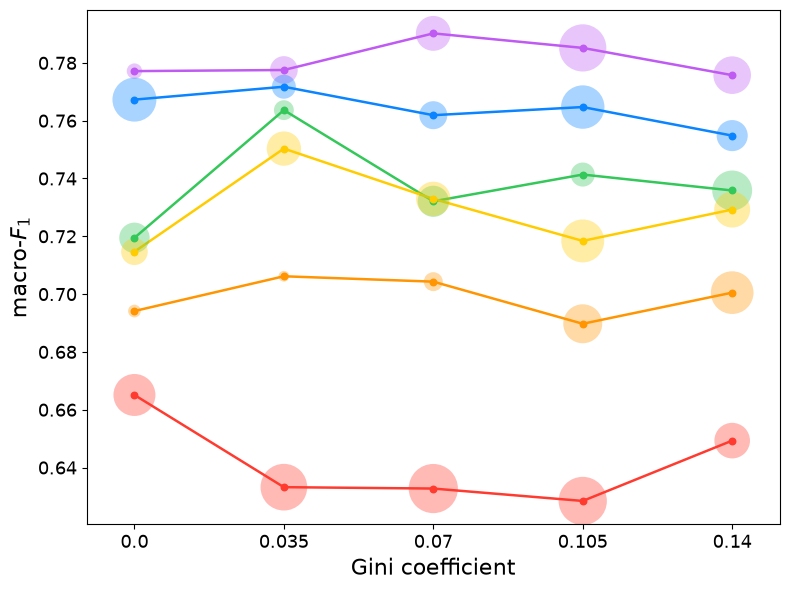

In [3]:
k = 900.0  # bubble diameter proportional to std -> scatter area s = (k * std)**2

fig, ax = plt.subplots(figsize=(8, 6))
for serial in MODEL_ORDER:
    pts = data.get(serial)
    if not pts:
        print(f"WARNING: no data for {serial}")
        continue
    exps = sorted(pts, key=lambda e: pts[e][0])
    xs = np.array([pts[e][0] for e in exps])
    ys = np.array([pts[e][1] for e in exps])
    ss = np.array([pts[e][2] for e in exps])
    color = MODEL_COLOR[serial]
    ax.plot(xs, ys, "-", lw=1.8, color=color, zorder=1)
    ax.scatter(xs, ys, s=(k * ss) ** 2, color=color, alpha=0.35, linewidths=0, zorder=2)
    ax.scatter(xs, ys, s=22, color=color, alpha=1.0, zorder=3, label=serial)

ax.set_xlabel("Gini coefficient", fontsize=16)
ax.set_ylabel(r"macro-$F_1$", fontsize=16)
ax.set_xticks(list(GINI.values()))
ax.set_xticklabels(["0.0", "0.035", "0.07", "0.105", "0.14"])
ax.tick_params(axis="both", which="major", labelsize=13)
ax.margins(x=0.08)

fig.tight_layout()
os.makedirs(OUT_DIR, exist_ok=True)
fig.savefig(OUT_PDF, bbox_inches="tight")
fig.savefig(OUT_PNG, dpi=150, bbox_inches="tight")
print("wrote", OUT_PDF)
plt.show()